# Category theory for programmers
## Chapter 1
- Categories have the following 3 important properties:
    1. Objects ($A,B,C ...$) -> for programming these will represent data types
    2. Morphisms ($f,g,h ...$) -> for programming these reflect functions
        - function is defined by the type it takes in and type it spits out (an arrow that moves from point A to point B on the graph)
            - $f$ :: $A \to B$ => takes input of type A and returns type B 
        - functions must be composable so if:
            - $f$ :: $A \to B$
            - $g$ :: $B \to C$
            - then $g \circ f$ :: $A \to C$
                - composition is read right->left takes $A$, applies $f$, then applies $g$
        - must be associative so: $h \circ g \circ h$ == $(h \circ g) \circ f$ == $h \circ (g \circ f)$
    3. Identity morphism ($id_{a} :: a \to a$) -> takes an object and returns that object
        - use lower case for variable types, upper case for concrete types
        - $id$ is also composable
            - $f \circ id_{A} == f$ 
            - $id_{B} \circ f == f$ in both of these compositions returns the function $f$

### Problem Set
1. Implement identity function in python

In [3]:
from typing import Any, TypeVar, ParamSpec, Callable, Union
from inspect import signature
import random
import math as mt

In [2]:
T = TypeVar("T")
R = TypeVar("R")

def id(x:T) -> T:
    return x

def f_func(x:Union[int, Callable]) -> Union[str, Callable]:
    #print("butt")
    try:
        assert isinstance(x,int), "need an int as input"
        return(str(x))
    except: 
        try:
            assert isinstance(x, Callable)
            return(f_func)
        except: return("No acceptable type given")
def g_func(y:Union[str,Callable]) -> Union[float,Callable]:
    #print("boob")
    try:
        assert isinstance(y,str), "need a string as input"
        return(float(y))
    except: 
        try:
            assert isinstance(y, Callable)
            return(g_func)
        except: return("No acceptable type given")
    
print(f_func(6))
print(type(f_func(id(6))))
print(id(f_func))
print(type(f_func(id)))
print(f_func("Chad"))


6
<class 'str'>
<function f_func at 0x108919da0>
<class 'function'>
No acceptable type given


2. Implement a composition function that takes two functions as argument and applies one to the other.

In [16]:
P = ParamSpec("P")

# This allows us to get the return type of some function -> need this to type check composition
def infer_return_type(func: Callable) -> type:
    return func.__annotations__.get('return', None)

# this takes any two functions, confirms output of first is input of second, and returns function composed of both
def composition(func1: Callable[P,T], 
                func2: Callable[T,R]) -> Callable[P,R]:
    #print(infer_return_type(func1))
    siggy = signature(func2)
    arg_types = [param.annotation for param in siggy.parameters.values()]
    for i in arg_types:
        print(i)
    assert ((infer_return_type(func1)) == arg_types[0] or arg_types[0] == T or infer_return_type(func1) == T), "Return of first function does not match input of second function"
    return(lambda x: func2(func1(x)))

h_func = composition(f_func, g_func)
print(h_func(6))
print(type(h_func(6)))

bad_func = composition(g_func, f_func)
print(bad_func(6))

typing.Union[str, typing.Callable]
6.0
<class 'float'>
typing.Union[int, typing.Callable]


AssertionError: Return of first function does not match input of second function

3. Write a program that tests that the composition function respects

In [117]:
# Testing both directions of composition
id_func1 = composition(id,f_func)
id_func2 = composition(f_func,id)

#Testing composition on a composed function (h = g o f)
id_func3 = composition(h_func,id)

print(id_func1(6))
print(id_func2(6))
print(id_func3(6))

6
6
6.0


### Now with Haskell
We can use jupyter notebooks with a haskell kernel as well yippee

In [1]:
identity :: a -> a
identity x = x

--identity 5

fFunc :: Integer -> String
fFunc x = show x

gFunc :: String -> Float
gFunc x  = read x

-- gFunc (fFunc 7)

-- because we take arguments x, y to x.y need to give the type conversion for outer function first
compose :: (b -> c) -> (a -> b) -> (a -> c)
compose x y = x . y

hFunc = compose gFunc fFunc
hFunc 6

iFunc = compose fFunc gFunc 

Line 7: Eta reduce
Found:
fFunc x = show x
Why not:
fFunc = showLine 10: Eta reduce
Found:
gFunc x = read x
Why not:
gFunc = read

6.0

4. Is the web a category? Are links morphisms?
    - Objects? Sites
    - Morphisms? links, take us from one site to the next.
        - composition? in some sense yes, clicking a link takes us to another page with another link which can take us to a third page/ in some other sense no, can't generate a link to take us from page 1 to 3, without changing the links on page 1
    - identity? yes? can have a link to the current page
5. Is facebook a category? -> as a website kinda
    - Objects: People, pages, groups
    - Morphisms: following, friending
        - composition no? in terms of navigating network maybe??????? but friending someone is not necessarilly composable with their friendships
    -  identity: can go to self
6.  When is a directed graph a category?
    - when a node can return to itself (identity) - not a simple directed graph
    - when it is a multigraph (can allow for multiple morphisms between the same objects)


## Chapter 2
Why typing?
- supports pre-run verification of programs by identifying and blocking functions with type-mismatches before runtime
- Typing is for supporting function composability and allows us to verify before run-time that a program will run
    - typing mismatches can be identified via formal proof, vs unit-testing
- types as sets of values - some finite (bool, Void, unit, Char, Int) and some infinite (Integer, String)
    - Can treat types as a Category of sets (**SET**)
        - Category of Haskell set (**Hask**)
            - has a bottom value ($\bot$) that reflects a function could potentially not resolve
                - $f :: Bool \to Bool$
                - $f = undefined$ or $f x = undefined$
            - this is because program functions need to run + resolve, while mathematical functions are always in resolved set   
What does a mathematical model buy us?
- *operational semantics*: describes the mechanics of program execution
  - hard to *prove* things about programs -> to show property need to run it through idealized interpreter
- *denotational semantics*: every programming construct has mathematical interpretation
  - proving program function, is then possible to do like a mathematical theorem
  - breakthrough for modelling less explicitly mathematical programs thanks to *Eugene Moggi* and his finding that computational effects can be mapped to monads => *Category Theory* useful for interpreting programs

Functions can be pure or dirty.
- *pure*: reliably execute target function consistently and no side-effects
- *dirty*: doesn't reliably execute target function and may have side effects (things that happen without explicit typed return)

Types:
- Void: In Haskell, not to be confused with C++ void
    - reflects absence of anything, maps to everything only 1 way
    - $absurd :: Void \to a$
    - from Waterloo -> initial object of category
- unit: In haskell, in C++ this is void
    - reflects singleton, value just is -> empty set
    - any type can be "nulled" by casting to unit
        - $f :: a -> ()$
        - $f \space x = ()$ or $f \space \_ = ()$
    - can also be used to pick single element of set reliably
        - $f44 :: () -> Integer$
        - $f44 \space () = 44$
- Bool: The two element set
    - $data \space Bool = True | False$
    - Functions from bool pick from two values of target type (one for true and one for false)
    - Functions to bool are predicates like $isAlpha$ or $isDigit$ 

### Problem Set
1. Define a memoize function:
    1. takes a pure function
    2. returns a function that is nearly identical except
    3. also stores the history of (input,output) pairs 
    4. use this dataset to return outputs for previously encountered inputs
    5. only run initial function for new inputs

In [79]:
def memoize (func: Callable[P,T]) -> Callable[P,T]:
    memoy_dic = {}
    #all of this bullshit is so that memoize can take input functions with variable argument sizes
    #we pull out the arg parameters, get their length, and generate a tuple of stand-in variable names
    arg_types = [param.annotation for param in signature(func).parameters.values()]
    inp_list = []
    for i in range(len(arg_types)):
        inp_list.append(f"a{i}")
    inps = tuple(inp_list)
    
    def memoy(*inps,
              lis: dict,
              func1: Callable[P,T]) -> T:
        print(lis)
        if inps in lis.keys():
            return lis[inps]   
        else:
            out = func1(*inps)
            lis[inps] = out
            return out
    def runner(*inps):
        # the little asterisk for the arguments serves the function of currying the inputs from the tuple
        return memoy(*inps, lis=memoy_dic, func1 = func)        
    return runner
    
mem_f_func = memoize(f_func)
print(mem_f_func(7000000000000))
#print(id(mem_f_func))
print(mem_f_func(4))
print(mem_f_func(7000000000000))
print(mem_f_func(5))

{}
7000000000000
{(7000000000000,): '7000000000000'}
4
{(7000000000000,): '7000000000000', (4,): '4'}
7000000000000
{(7000000000000,): '7000000000000', (4,): '4'}
5


#### Andrew's python version.
Way more nice than mine ;___;

In [86]:
from collections.abc import Callable
from typing import ParamSpec, TypeVar

P = ParamSpec("P")
R = TypeVar("R")

Key = tuple[
    tuple[object, ...],
    tuple[tuple[str, object], ...],
]


def memoize(function: Callable[P, R]) -> Callable[P, R]:
    table: dict[Key, R] = {}
    def memoized(*args: P.args, **kwargs: P.kwargs) -> R:
        key: Key = (
            tuple(args),
            tuple(sorted(kwargs.items(), key=lambda item: item[0])),
        )
        if key not in table:
            table[key] = function(*args, **kwargs)
        return table[key]

    return memoized


@memoize
def fibonacci(n: int) -> int:
    return n if n < 2 else fibonacci(n - 1) + fibonacci(n - 2)

2. Does memoize work on a random number generation function - lol no. Will keep returning the same number

In [85]:
mem_random = memoize(random.randint)
print(mem_random(1,5100))
print(mem_random(1,5100))

{}
3446
{(1, 5100): 3446}
3446


3. Make a function that takes inital seed for random function, returns random value. Memp

In [83]:
def seeded_randint(seed:int = 0,
                   start:int = 0,
                   end:int = 5000):
    random.seed(seed)
    return random.randint(start,end)
    

seedy = memoize(seeded_randint)
print(seedy(5))
print(seedy(5))
print(seedy(5,5))
print(seedy(5,10,20))
print(seedy(4))
print(seedy())
print(seedy())

{}
2092
{(5,): 2092}
2092
{(5,): 2092}
2097
{(5,): 2092, (5, 5): 2097}
19
{(5,): 2092, (5, 5): 2097, (5, 10, 20): 19}
1933
{(5,): 2092, (5, 5): 2097, (5, 10, 20): 19, (4,): 1933}
3155
{(5,): 2092, (5, 5): 2097, (5, 10, 20): 19, (4,): 1933, (): 3155}
3155


4. No clue I ain't learning C for this.
    - a) pure
    - b) ????
    - c) dirty -> the std::cout call??
    - d) ?????? pure but also shouldn't the function not work at all?
5. How many different functions from Bool -> Bool? Implementable?
    - 4
   1) T = T, F = F
   2) T = T, F = F
   3) T = F, F = F
   4) T = F, F = T
6. 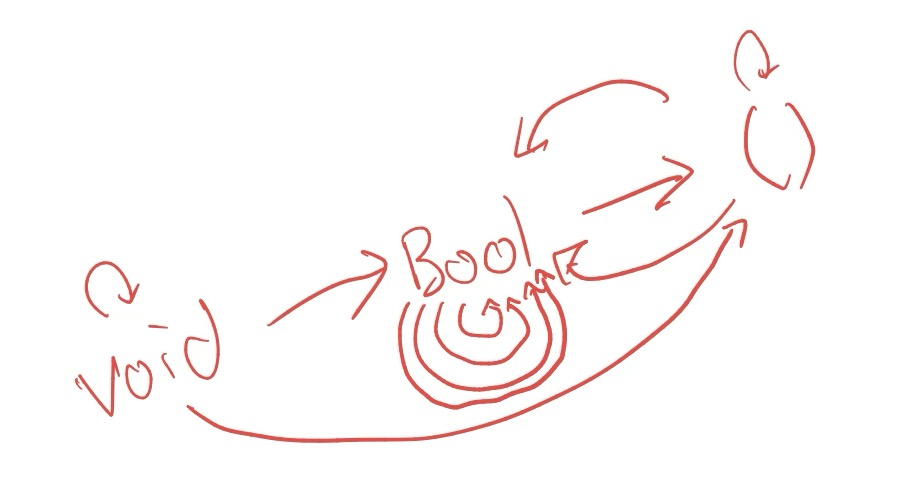 

## Chapter 3
 This chapter gives a quick pass through some example Categories, and also Monoids. 
 The organization of this book is really something. 
 - *free construction*: complete a structure by giving it a minimum number of items to satisfy its laws -> in our case here, making a category
 - set of morphisms from some object $a$ to some object $b$ in a category $C$ is the hom-set
     - written as $C(a,b)$ or $\textbf{Hom}_{C}(a,b)$ 
 ### The empty category
 Has no bitches(objects)
 In the category of categories it acts like the unit type (in the category of types)?

 ### Simple Graphs
 Simple directed graph can be converted into a category by:
 - adding identity morphisms
 - add arrows which are compositions of existing arrows

 Creates a category where every node is an object, and all possible composable graph edges as morphisms
- This is a *free category* => example of *free construction*
    
 
 ### Orders
 - A category where the morphism is a relation between objects 
     - for example the *preorder* of less than and equal to ($\leq$)
         - has an identity -> any object will be equal to itself
         - has composition -> if $a \leq b$ and $b \leq c$ then $a \leq c$
         - there is at most one morphism from any object $a$ to $b$
             - category is thin
             - hom-set is either empty or singleton
             - may have cycles
     - a *partial order* would impose the stronger condition that:
         - if $a \leq b$ and $b \leq a$ than $a = b$
         - cycles forbidden
     - a *total order*/*linear order*
         - any two objects are in a relation with each other
         - sorting algorithms only work on these kinds of orders

 ### Monoid Described As A Set
 A monoid is a set with a binary operation
 - operation must be associative
 - operation must have a special element that acts as a unit (i.e 0 for addition, 1 for multiplication)

 For example:
 - natural numbers (including 0) form a monoid under addition:
     - associative: $a + (b + c)$ = $(a + b) + c$ so $a + b +c$
     - neutral element is 0: $a + 0 = a$ and $0 + a = a$
 - also form a monoid under multiplication:
     - associative: $(a * b) * c$ = $a * (b * c)$
     - neutral element is 1: $a * 1$ = $a$

 In Haskell can define a type class for monoids:
 ```
 class Monoid m where
     mempty  :: m --defines the neutral element
     mappend :: m -> m -> m --defines the binary operation 
 ```
 - uses currying in the type description for mappend (m -> m -> m), reflects function taking first argument of type m, then second of same type, then returning output of same type
     - can also be interpreted as type signature of a function taking one type, and returning a function of specified type
 - can't explicitly state monoidal properties of mempty and mappend in Haskell, responsibility of programmer to make sure properties are satisfied for both
 Example for string concatenation monoid:
 ```
 isinstance Monoid String where
     mempty  = ""
     mappend = (++)
 ```
 - ++ is the concatenate function, infixed usually, can turn into 2-arg func with ()
     - (++) str1 str2 == str1 ++ str2
  
 Haskell allows us to express equality of morphisms (functions) and equality of objects (values produced ny functions)
 - look the same kind of in Haskell
 - equality of a morphism - *point-free*:
     ```
     mappend = (++)
     ```
 - equality of object - objects/values are called *points*:
     ```
     mappend s1 s2 = (++) s1 s2
     ```
 ### Monoid As A Category
 - consider the application of the binary operator as moving things around the set?
 For monoid with binary operator of addition:
 - there's a function for ever $n \in N$ that is "the adder" of that natural number
 - adders can compose => and can be made identical to addition
     - that is we can replace addition with function composition
     - this looks like the interpretation of m -> m -> m where the latter m -> m defines a function (the adder) => that is monoid maps element of set to function on set
 - can have adder of neutral number 0
     - works as identity => does not move around set
  
 Monoid is a single object Category with set of morphisms that follow rules of composition
 - have a hom-set $\textbf{M}(m,m)$ of the single object $m$ => defines all possible morphisms that satisfy properties of monoid
     - the type of the set of interest itself is the object of the monoid -> and it has two "types" of morphisms (mappend, mempty), but multiple possible distinct morphisms of that "type"
         - these distinct morphisms are the "elements" of the monoid M 
     - can define a binary operator in the hom-set
         - monoidal product of 2 set-elements is the element of the composition of the corresponding morphisms
         - take 2 elements of $\textbf{M}(m,m)$ corresponding to $f$ and $g$, product will correspond to $f \circ g$
         - therefore can always recover set monoid from category monoid
             -  use the identity with any two morphisms and you recover the whole set

### Problem Set
1. 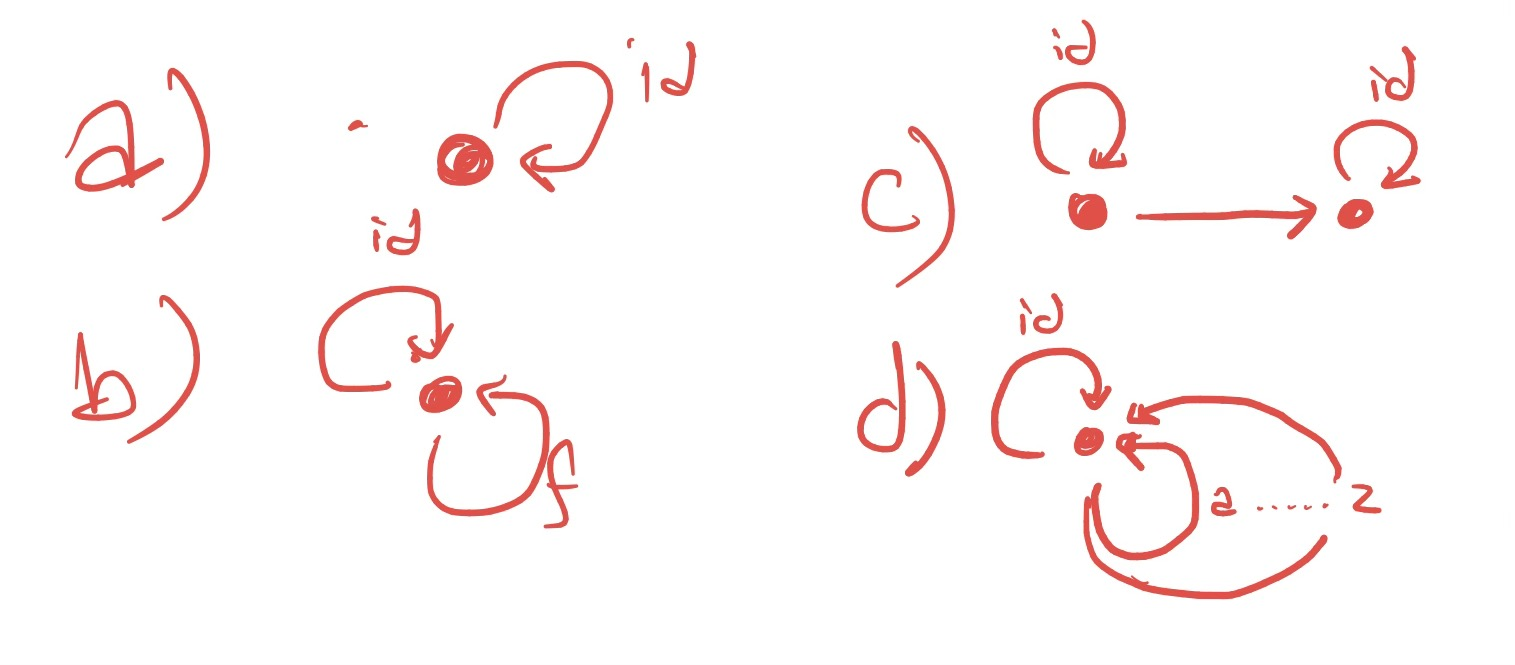
    -  b and d have infinite morphisms
2. What kind of order is this?
   - a set of sets with the inclusion criteria that A is included in B if $\forall x \in A \implies x \in B$
       - inclusion is morphism between sets
       - set is included in itself -> identity 
       - partial order -> prevents cycles via axiom of extensionality
           - if $A \subseteq B$ and $B \subseteq A$ then $A = B$
           - if $A \subseteq B$, $x \in A \implies x \in B$
           - if $B \subseteq A$, $x \in B \implies x \in A$
           - by axiom of extensionality $A = B$
               - if $(\forall x) \space x \in A \iff x \in B \implies A = B$       
   - gibberish about C
3. Bool is a set of two values ($True$ and $False$), show that it forms monoids with respect to $AND$ and $OR$
    1. $AND$:
        - is associative: $(Bool \space AND \space Bool) \space AND \space Bool = Bool \space AND \space (Bool \space AND \space Bool)$
            - i.e (T && T) && F == T && (T && F)
        -   $TRUE$ acts as the neutral element
            - T && T = T
            - T && F = F
    2. $OR$:
        - is associative i.e: T || (T || F) = (T || T) || F
        - $FALSE$ acts as the neutral element
            - T || F = T
            - F || F = F
4. Represent the $Bool$ monoid with $AND$ operator as a category
    - $\textbf{Hom}_{BAND}(Bool,Bool) = \{\&\& True, \&\& False\}$
    - $id \circ \&\&T = \&\&T \circ id = \&\&T$ -> same with F
    - $\&\& Bool \circ \&\&Bool = \&\&Bool$ -> always exists because source and target is same object($Bool$)
    - Andrew's answer uses $AND$ as composition, with $TRUE$ and $FALSE$ as the morphisms => isomorphic answer
5. Represent addition modulo 3 as a monoid
    - $M(\bullet, 0)$ - where $\bullet$ represents addition modulo 3, or our operation 
    - $\textbf{Hom}_{am3}(n,n) = \{ \forall n \in \{0,1,2,3\}, +n_{3} \}$
    - $0 + n_{3} = n_3 + 0 = n_{3}$
    - $\exists +n_{3} \circ +n_{3}$
    

## Chapter 4
### Kleisli Categories
- how to make pure functions, that can do side effect bullshit
- the Kleisli category, is the same category as the category of types (including custom types), but it also defines an endofunctor that maps objects and morphisms to other objects in morphisms in that category
#### Definition
- 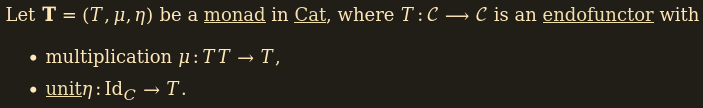
- 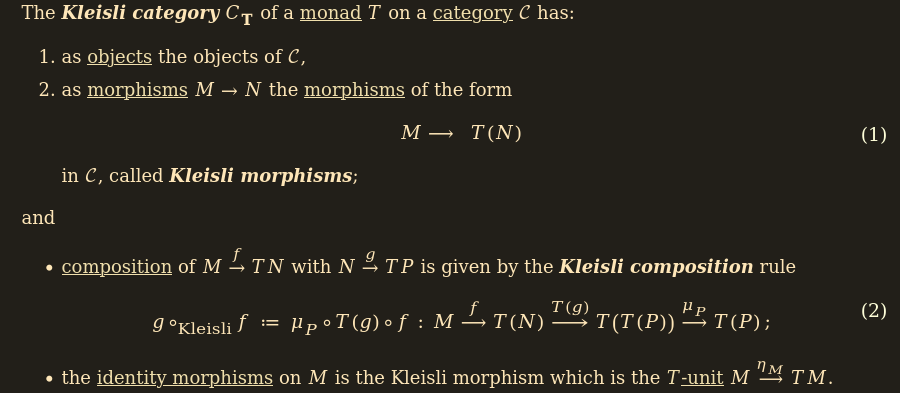
#### Practical explanation
- the functions/morphisms for a Kleisli category (kleisli morphisms), take a basic type and output a transformed/embellished form of a target type
    - $f = M \to T(N)$
    - in this case the "target" output type is $N$, and the embellishment is used to handle side-effects in a structured way
- also need to define a kleisli composition function: given two kleisli morphisms, define the composition function such that:
    - $f = M \to T(N)$
    - $g = N \to T(P)$
    - $g \circ_{Kleisli} f = M \xrightarrow{\text{f}} N \xrightarrow{\text{T(g)}} T(T(P)) \xrightarrow{{\mu_{P}}} T(P) \implies M \to T(P)$
    - so here the composition function, is able to strip and hold onto the embellished output for $f$, pass the basic output of $f$ to $g$ and then take the embellished output of $g$, combine its embellishment with the embellishment of $f$ and pass it out
- also need an identity morphism -? should pass argument without change, with the embellishment (but the unit of it)

### Problem Set
1) Construct kleisli category for partial function with the optional embellished type
    - define composition + identity
2) Implement safe_reciprocal
3) compose safe_root and safe_reciprocal to calculate the safe reciprocal root (sqrt(1/x))

In [30]:
T = TypeVar("T")
type Partial[bool,T] = tuple[bool, T]

def safe_root(x:Union[int,float]) -> Partial:
    assert isinstance(x, Union[int,float]), "Need a number as an input."
    if x >= 0:
        p: Partial = (True, mt.sqrt(x) )
        return p
    else:
        p: Partial = (False, )
        return p

def safe_reciprocal(x:Union[int,float]) -> Partial:
    assert isinstance(x, Union[int,float]), "Need a number as an input."
    if x != 0:
        p: Partial = (True, 1/x )
        return p
    else:
        p: Partial = (False, )
        return p

def infer_return_type(func: Callable) -> type:
    return func.__annotations__.get('return', None)

def partial_composition(func1:Callable[T,Partial],
                        func2:Callable[T,Partial]) -> Callable[T,Partial]:
    def compose (x:T):
        z = func1(x)
        siggy = signature(func2)
        arg_types = [param.annotation for param in signature(func2).parameters.values()]
        assert isinstance(z[1],arg_types[0]) #wrong output type for func1, given input type of func2
        if z[0] == True:    
            y = func2(z[1])
            print(y)
            print(z)
            if y[0] == True:
                return(y[0] + z[0],y[1])
            else:
                p: Partial = (False,)
                return p
        else:
            p: Partial = (False,)
            return p
    return compose
def partial_identity(x:T) -> Partial:
    p: Partial = (True,x)
    return p

print(safe_root(-4))
print(safe_root(4))
print(safe_reciprocal(-4))
print(safe_reciprocal(0))
butt = partial_composition(safe_reciprocal,safe_root)
print(butt(4))
print(butt(-4))
#print(butt("boob"))
print(partial_identity(butt))

(False,)
(True, 2.0)
(True, -0.25)
(False,)
(True, 0.5)
(True, 0.25)
(2, 0.5)
(False,)
(True, -0.25)
(False,)
(True, <function partial_composition.<locals>.compose at 0x7efc449e2840>)


## Chapter 5
### Initial and Terminal objects
#### Initial object
- simplest shape of a category (simplest object with simplest relations)
- acts as the *unique up to unique isomorphisms* starting point of the morphisms in the categories -> one that has arrows going to all other objects
- definition:
    - the **initial object** is the object that has one and only one morphism going to any object in the category
- isomorphism of any two initial objects
#### Terminal object
- definition
    - the **terminal object** is the object with one and only one morphism coming to it from any object
- also unique up to isomorphism => uniqueness is critical
### Duality
- category $C$ and it's inverse $C_{op}$
    - given morphisms in $C$:
        - $f :: a \to b$
        - $g :: b \to c$
        - $h :: a \to c = g \circ f$
    - inverse morphisms in $C_{op}$ also follow composition:
        - $f^{op} :: b \to a$
        - $g^{op} :: c \to b$
        - $h^{op} :: c \to a = f^{op} \circ g^{op}$
    - inverse identity is a no-op => they stay the same
- duality in constructions in category are preceded with *co*-prefix:
    - monad and comonad
    - product and coproduct
    - the co-intial object is the terminal object and vice-versa
### Isomorphism
- intuition: objects have the same shape, every part of one corresponds to every part of other in one-to-one mapping
- an invertible morphism - pair of morphisms where they are inverse of the other
    - morphisms are inverses if their compositions are identity
        - $f \circ g = id$
        - $g \circ f = id$  